In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
data = {

    'layout': ['A', 'B', 'C' , 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],

    'meeting_adjacency':  [9, 8, 10, 8, 8, 6, 9, 7, 9, 5, 8, 9],

    'conference_access':  [7, 7, 8, 8, 8, 7, 8, 7, 10, 6, 8, 9],

    'cabin_proximity':    [8, 9, 9, 8, 7, 5, 8, 7, 8, 4, 7, 8],

    'circulation':        [7, 9, 10, 6, 6, 4, 8, 5, 8, 3, 7, 7],

    'crossing_flow':      [2, 8, 0, 6, 5, 3, 8, 4, 7, 2, 5, 7],

    'pantry_zoning':      [5, 5, 2, 7, 9, 4, 6, 6, 7, 3, 6, 7],

    'density':            [0, 2, 2, 8, 8, 7, 9, 6, 8, 6, 8, 8],

}

df = pd.DataFrame(data)

df

,layout,meeting_adjacency,conference_access,cabin_proximity,circulation,crossing_flow,pantry_zoning,density
0,A,9,7,8,7,2,5,0
1,B,8,7,9,9,8,5,2
2,C,10,8,9,10,0,2,2
3,D,8,8,8,6,6,7,8
4,E,8,8,7,6,5,9,8
5,F,6,7,5,4,3,4,7
6,G,9,8,8,8,8,6,9
7,H,7,7,7,5,4,6,6
8,I,9,10,8,8,7,7,8
9,J,5,6,4,3,2,3,6


In [ ]:
df_suggestions = {
    'circulation_percent':[27.16,25.67,23.28, 31.56 ,27.21,34.08, 29.94, 30.01, 35.12, 26.74, 39.21, 20.35],

    'area_per_person':    [2,3,3,7.1,8.0,6.9,7.5,7.2,6.4,8.3,4.4,5.2],

    'avg_adjacency':      [5.98,6.56,5.13,7.0,7.5,5.8,7.3,6.8,5.5,8.5,4.6,9.3]}

df_suggestions = pd.DataFrame(df_suggestions)

df_suggestions

,circulation_percent,area_per_person,avg_adjacency
0,27.16,2.0,5.98
1,25.67,3.0,6.56
2,23.28,3.0,5.13
3,31.56,7.1,7.00
4,27.21,8.0,7.50
5,34.08,6.9,5.80
6,29.94,7.5,7.30
7,30.01,7.2,6.80
8,35.12,6.4,5.50
9,26.74,8.3,8.50


Define Weights

In [ ]:
weights = {

    'meeting_adjacency': 20,

    'conference_access': 15,

    'cabin_proximity': 15,

    'circulation': 20,

    'crossing_flow': 10,

    'pantry_zoning': 10,

    'density': 10

}

Calculate Weighted Efficiency Score

In [ ]:
efficiency_scores = []

for index, row in df.iterrows():              #index: The row label (identifier) for the current row.   #row: The data of that row represented as a Pandas Series.

    total_score = 0

    max_possible_score = 0

    for feature, weight in weights.items():

        total_score += row[feature] * weight

        max_possible_score += 10 * weight


    efficiency = (total_score / max_possible_score) * 100

    efficiency_scores.append(round(efficiency, 2))


df['efficiency_score'] = efficiency_scores

df

,layout,meeting_adjacency,conference_access,cabin_proximity,circulation,crossing_flow,pantry_zoning,density,efficiency_score
0,A,9,7,8,7,2,5,0,61.5
1,B,8,7,9,9,8,5,2,73.0
2,C,10,8,9,10,0,2,2,69.5
3,D,8,8,8,6,6,7,8,73.0
4,E,8,8,7,6,5,9,8,72.5
5,F,6,7,5,4,3,4,7,52.0
6,G,9,8,8,8,8,6,9,81.0
7,H,7,7,7,5,4,6,6,61.0
8,I,9,10,8,8,7,7,8,83.0
9,J,5,6,4,3,2,3,6,42.0


Auto-Generated Design Suggestions


In [ ]:
def generate_suggestions(row):

    suggestions = []

    if row['meeting_adjacency'] < 6:
        suggestions.append(
            "Improve meeting room accessibility to workspace"
        )

    if row['circulation'] < 5:
        suggestions.append(
            "Reduce excessive circulation area"
        )

    if row['crossing_flow'] <= 0:
        suggestions.append(
            "Reduce movement through focused work areas"
        )

    if row['pantry_zoning'] < 5:
        suggestions.append(
            "Relocate pantry away from focused workspace"
        )

    if row['density'] < 5:
        suggestions.append(
            "Increase area per person to improve comfort"
        )

    if row['circulation_percent'] > 35:
        suggestions.append(
            "Reduce excessive circulation area"
        )

    if row['area_per_person'] < 4:
        suggestions.append(
            "Workspace density is high"
        )

    if row['avg_adjacency'] < 6:
        suggestions.append(
            "Improve spatial relationships between key spaces"
        )

    return suggestions

Apply suggestions

In [ ]:
df['circulation_percent'] = df_suggestions['circulation_percent']
df['area_per_person'] = df_suggestions['area_per_person']
df['avg_adjacency'] = df_suggestions['avg_adjacency']

df['suggestions'] = df.apply(
    generate_suggestions,
    axis=1
)

df[['layout',
    'efficiency_score',
    'suggestions']]

,layout,efficiency_score,suggestions
0,A,61.5,"[Increase area per person to improve comfort, Workspace density is high, Improve spatial relationships between key spaces]"
1,B,73.0,"[Increase area per person to improve comfort, Workspace density is high]"
2,C,69.5,"[Reduce movement through focused work areas, Relocate pantry away from focused workspace, Increase area per person to improve comfort, Workspace density is high, Improve spatial relationships between key spaces]"
3,D,73.0,[]
4,E,72.5,[]
5,F,52.0,"[Reduce excessive circulation area, Relocate pantry away from focused workspace, Improve spatial relationships between key spaces]"
6,G,81.0,[]
7,H,61.0,[]
8,I,83.0,"[Reduce excessive circulation area, Improve spatial relationships between key spaces]"
9,J,42.0,"[Improve meeting room accessibility to workspace, Reduce excessive circulation area, Relocate pantry away from focused workspace]"


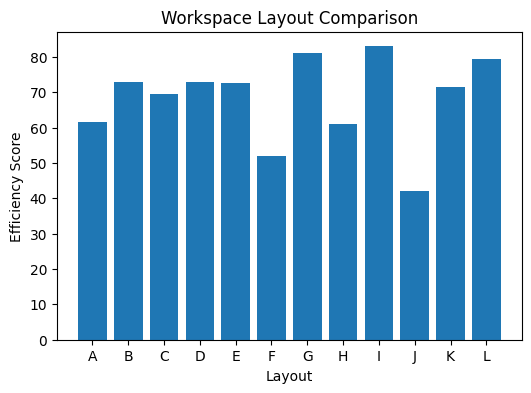

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(df['layout'],
        df['efficiency_score'])

plt.xlabel("Layout")

plt.ylabel("Efficiency Score")

plt.title("Workspace Layout Comparison")

plt.show()

Prepare Features X and y

In [ ]:
X = df.drop(columns=['layout', 'efficiency_score', 'suggestions'])
X

,meeting_adjacency,conference_access,cabin_proximity,circulation,crossing_flow,pantry_zoning,density,circulation_percent,area_per_person,avg_adjacency
0,9,7,8,7,2,5,0,27.16,2.0,5.98
1,8,7,9,9,8,5,2,25.67,3.0,6.56
2,10,8,9,10,0,2,2,23.28,3.0,5.13
3,8,8,8,6,6,7,8,31.56,7.1,7.00
4,8,8,7,6,5,9,8,27.21,8.0,7.50
5,6,7,5,4,3,4,7,34.08,6.9,5.80
6,9,8,8,8,8,6,9,29.94,7.5,7.30
7,7,7,7,5,4,6,6,30.01,7.2,6.80
8,9,10,8,8,7,7,8,35.12,6.4,5.50
9,5,6,4,3,2,3,6,26.74,8.3,8.50


In [ ]:
y = df['efficiency_score']
y

,efficiency_score
0,61.5
1,73.0
2,69.5
3,73.0
4,72.5
5,52.0
6,81.0
7,61.0
8,83.0
9,42.0


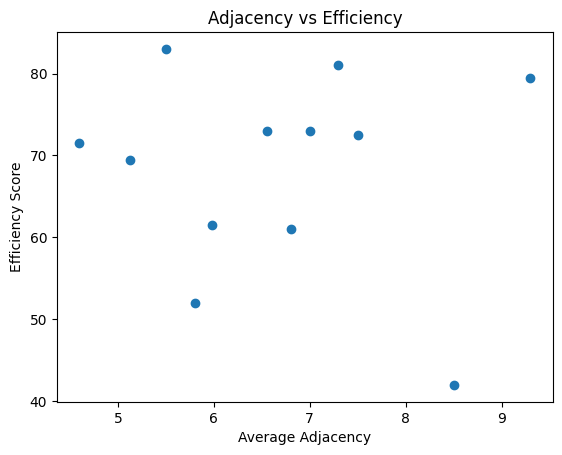

In [ ]:
plt.scatter(
    df['avg_adjacency'],
    df['efficiency_score']
)
plt.xlabel("Average Adjacency")
plt.ylabel("Efficiency Score")
plt.title("Adjacency vs Efficiency")

plt.show()

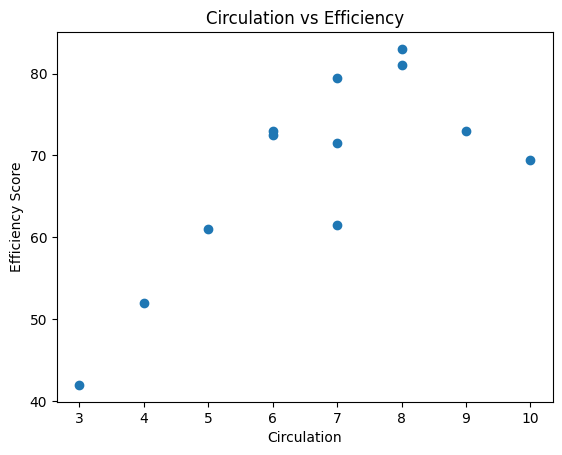

In [ ]:
plt.scatter(
    df['circulation'],
    df['efficiency_score']
)
plt.xlabel("Circulation")
plt.ylabel("Efficiency Score")
plt.title("Circulation vs Efficiency")

plt.show()

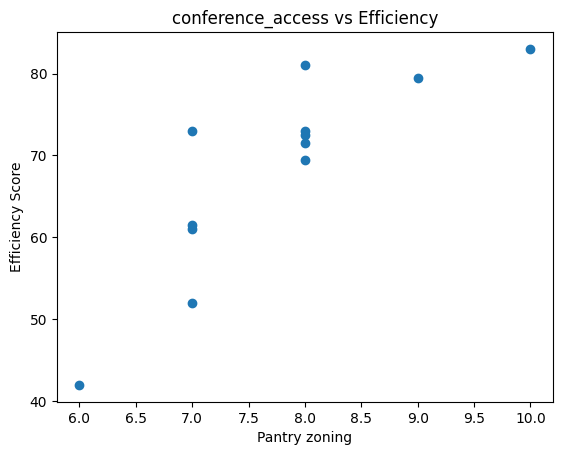

In [ ]:
plt.scatter(
    df['conference_access'],
    df['efficiency_score']
)
plt.xlabel("Pantry zoning")
plt.ylabel("Efficiency Score")
plt.title("conference_access vs Efficiency")

plt.show()

Split Train/Test Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

Train the Model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [ ]:
predictions = model.predict(X_test)

predictions

array([71.37848037, 42.00055078, 61.1349821 ])

Compare Real vs Predicted

In [ ]:
comparison = pd.DataFrame({

    'Actual': y_test,

    'Predicted': predictions
})

comparison

,Actual,Predicted
10,71.5,71.378480
9,42.0,42.000551
0,61.5,61.134982


Evaluate Accuracy using Mean Absolute Error

In [ ]:
error = mean_absolute_error(
    y_test,
    predictions
)

print(error)

0.16236277075680997


Feature Importance

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': model.coef_

})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
3,circulation,2.024864
0,meeting_adjacency,1.862527
2,cabin_proximity,1.569797
1,conference_access,1.540921
6,density,1.037063
4,crossing_flow,1.002072
5,pantry_zoning,0.984473
8,area_per_person,0.027227
7,circulation_percent,-0.027202
9,avg_adjacency,-0.079821


In [ ]:
corr = df.corr(numeric_only=True)

corr['efficiency_score'].sort_values(ascending=False)

,efficiency_score
efficiency_score,1.000000
conference_access,0.840425
meeting_adjacency,0.807154
cabin_proximity,0.796322
circulation,0.741099
crossing_flow,0.694575
pantry_zoning,0.587829
density,0.287449
circulation_percent,0.002102
avg_adjacency,-0.075508


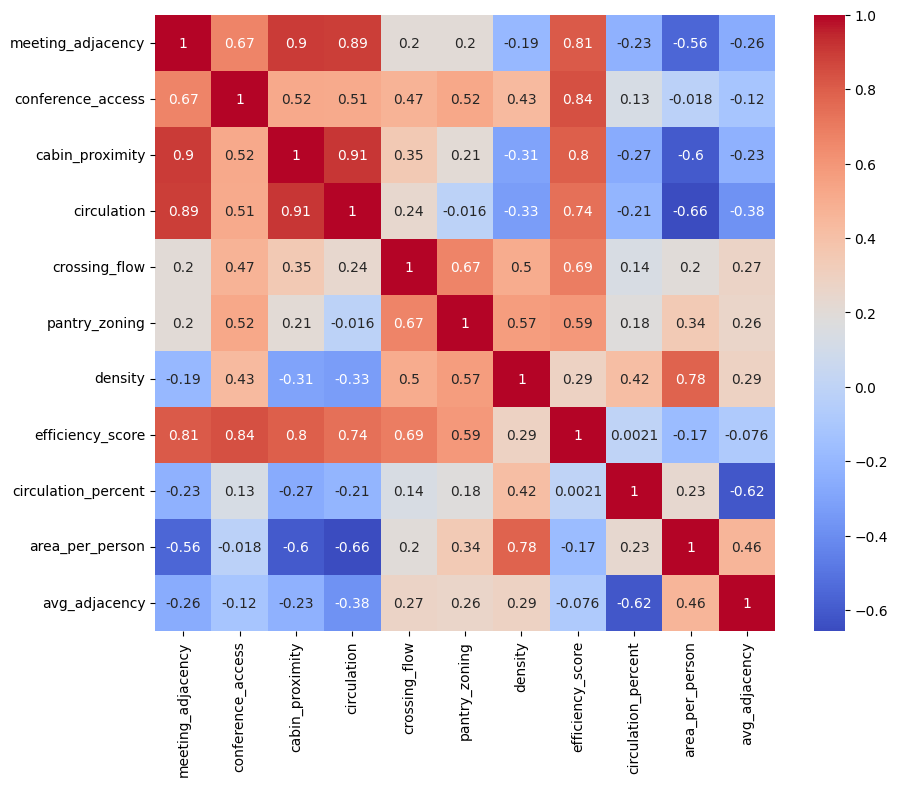

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

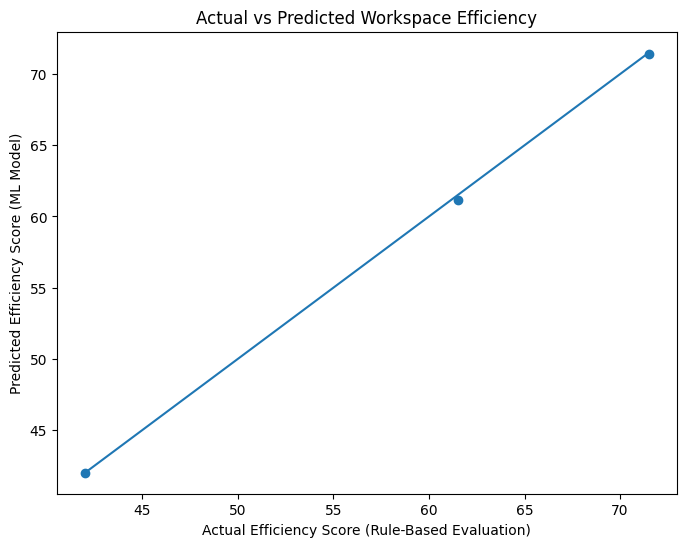

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, predictions)

# Reference line (perfect prediction line)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Efficiency Score (Rule-Based Evaluation)")
plt.ylabel("Predicted Efficiency Score (ML Model)")
plt.title("Actual vs Predicted Workspace Efficiency")

plt.show()

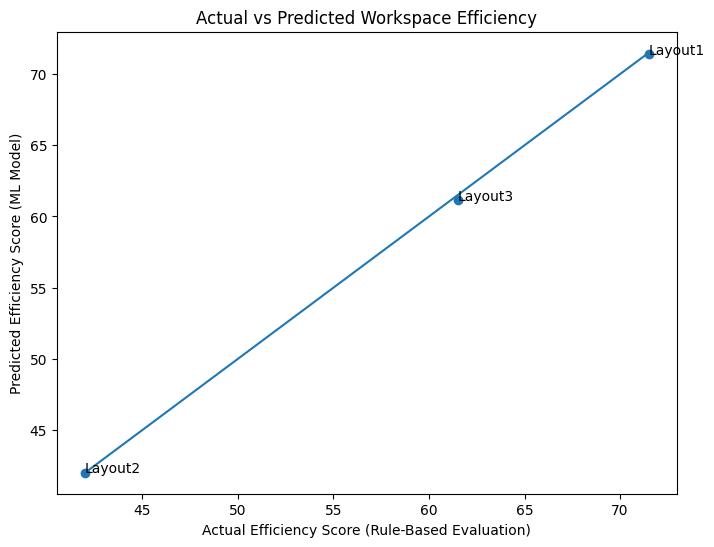

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

# Add ideal prediction line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)]
)

# Label points
for i in range(len(y_test)):
    plt.annotate(
        f"Layout{i+1}",
        (list(y_test)[i], predictions[i])
    )

plt.xlabel("Actual Efficiency Score (Rule-Based Evaluation)")
plt.ylabel("Predicted Efficiency Score (ML Model)")
plt.title("Actual vs Predicted Workspace Efficiency")

plt.show()